In [ ]:
from PIL import Image
import numpy as np

def generate_sliding_window_hex(image_path, output_hex):
    # 1. Load image and convert to 8-bit grayscale
    img = Image.open("salt_pepper_girl_512x512.gif").convert('L')
    img = img.resize((512, 512))
    data = np.array(img)

    height, width = data.shape

    with open(output_hex, 'w') as f:
        # 2. Slide the 3x3 window
        # We stop at height-2 and width-2 to stay within bounds
        for y in range(height - 2):
            for x in range(width - 2):
                # Extract the 3x3 neighborhood
                window = data[y:y+3, x:x+3]

                # Flatten the 3x3 to a list of 9 pixels
                pixels = window.flatten()

                # Convert each pixel to 2-digit hex
                hex_pixels = [f"{p:02x}" for p in pixels]

                # Write the 9 inputs separated by spaces
                f.write(" ".join(hex_pixels) + "\n")

    print(f"Success! Generated windows for a {width-2}x{height-2} filtered image.")
    print(f"File saved as: {output_hex}")

# Run the generator
generate_sliding_window_hex('input_image.jpg', 'girl_output.hex')

Success! Generated windows for a 510x510 filtered image.
File saved as: girl_output.hex


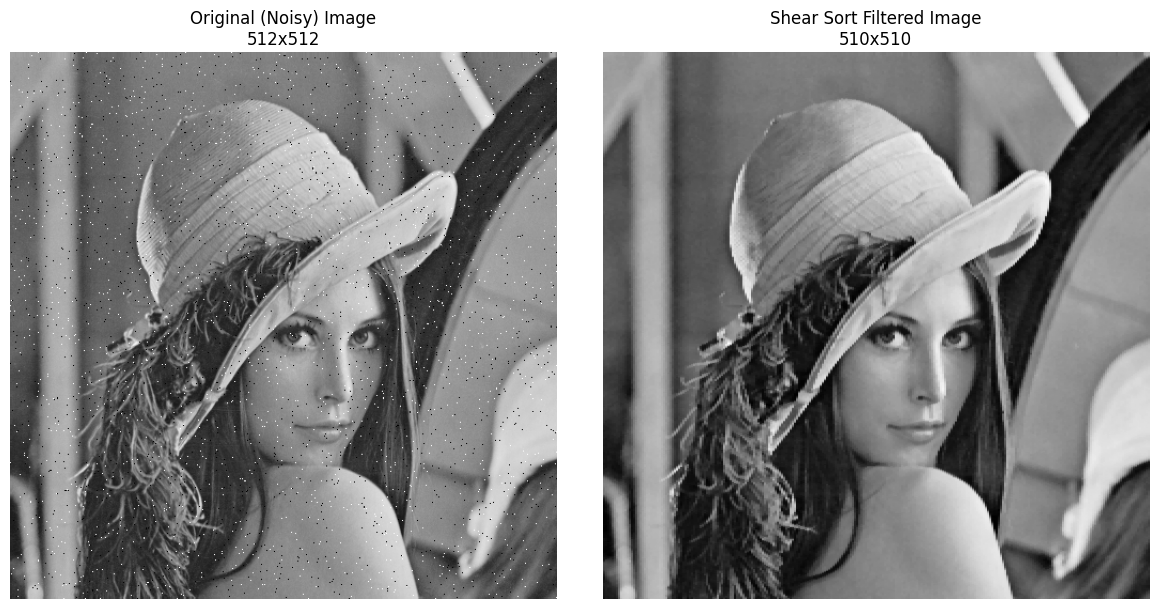

Comparison saved as 'comparison_result.png'


<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def compare_results(original_img_path, hex_output_path):
    # 1. Load the Original Image
    original = Image.open("salt_pepper_girl_512x512.gif").convert('L')
    original = original.resize((512, 512)) # Ensure it matches input size
    original_arr = np.array(original)

    # 2. Read the Hex Output from Verilog (510x510)
    pixels = []
    try:
        with open(hex_output_path, 'r') as f:
            for line in f:
                val = line.strip()
                if val:
                    pixels.append(int(val, 16))

        # Reshape to 510x510 (Result of 3x3 sliding window on 512x512)
        filtered_arr = np.array(pixels, dtype=np.uint8).reshape((510, 510))

        # 3. Plotting the Comparison
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # Left: Original
        axes[0].imshow(original_arr, cmap='gray')
        axes[0].set_title("Original (Noisy) Image\n512x512")
        axes[0].axis('off')

        # Right: Filtered
        axes[1].imshow(filtered_arr, cmap='gray')
        axes[1].set_title("Shear Sort Filtered Image\n510x510")
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

        # Save the result for your report
        plt.savefig("comparison_result.png")
        print("Comparison saved as 'comparison_result.png'")

    except FileNotFoundError:
        print(f"Error: {hex_output_path} not found. Run your Verilog simulation first.")
    except Exception as e:
        print(f"Error during reconstruction: {e}")

# Usage
compare_results('salt_pepper_girl_512x512.gif', 'image_output_girl_3x3.hex')

In [ ]:
import numpy as np
import math

def calculate_shear_sort_metrics(input_hex="girl_output.hex", output_hex="image_output_girl_3x3.hex"):
    try:
        # 1. Load Filtered Output (the result from your Verilog simulation)
        with open(output_hex, 'r') as f:
            out_data = [int(line.strip(), 16) for line in f if line.strip()]

        # 2. Load the "Center" pixels from the sliding window input
        # We take the 5th value (index 4) because that is the pixel
        # the filter was trying to 'clean' in that specific window.
        in_data = []
        with open(input_hex, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 9:
                    # Index 4 is the middle pixel (in5) of the 3x3 grid
                    in_data.append(int(parts[4], 16))

        # Ensure both arrays are the same length for comparison
        min_len = min(len(out_data), len(in_data))
        out_arr = np.array(out_data[:min_len], dtype=np.float64)
        in_arr = np.array(in_data[:min_len], dtype=np.float64)

        # 3. Calculate MSE (Mean Squared Error)
        mse = np.mean((in_arr - out_arr) ** 2)

        # 4. Calculate PSNR (Peak Signal-to-Noise Ratio)
        if mse == 0:
            psnr = 100.0  # Perfect match
        else:
            max_pixel = 255.0
            psnr = 20 * math.log10(max_pixel / math.sqrt(mse))

        # 5. Calculate Noise Removal Intensity (Standard Deviation of the difference)
        diff = in_arr - out_arr
        noise_removed_std = np.std(diff)

        print("-" * 40)
        print(f"SHEAR SORT HARDWARE METRICS")
        print("-" * 40)
        print(f"Total Pixels Compared:  {min_len}")
        print(f"Mean Squared Error:     {mse:.2f}")
        print(f"Peak SNR (PSNR):        {psnr:.2f} dB")
        print(f"Cleaning Intensity:     {noise_removed_std:.2f} levels")
        print("-" * 40)

        return mse, psnr

    except Exception as e:
        print(f"Calculation Error: {e}")

# Execute
calculate_shear_sort_metrics()

----------------------------------------
SHEAR SORT HARDWARE METRICS
----------------------------------------
Total Pixels Compared:  260100
Mean Squared Error:     281.66
Peak SNR (PSNR):        23.63 dB
Cleaning Intensity:     16.78 levels
----------------------------------------


(np.float64(281.662891195694), 23.63350727977049)